In [76]:
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , TensorDataset

In [77]:
transform = transforms.ToTensor()

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

In [78]:
class VAE(nn.Module):
    
    def __init__(self , indim=784 , hiddim=200 , latdim=20):
         super().__init__()
         
         
         #encoder
         self.fc1=nn.Linear(indim , hiddim)
         self.encoder_mew=nn.Linear(hiddim , latdim)
         self.encoder_var=nn.Linear(hiddim , latdim)
         
         #decoder
         self.fc2 = nn.Linear(latdim, hiddim)
         self.fc3 = nn.Linear(hiddim, indim)
         
    def encode(self , x):
        
        h=F.relu(self.fc1(x))
        l_mew=self.encoder_mew(h)
        l_var=self.encoder_var(h)
        
        return l_mew , l_var
        
    def reparameterize(self , l_mew , l_var):
        
        std=torch.exp(0.5 *l_var)
        eps = torch.randn_like(std)
        
        z = l_mew + eps * std
        
        return z 
    
    def decode(self, z):

        h = F.relu(self.fc2(z))

        x_hat = self.fc3(h)

        return x_hat
    
    def forward(self, x):

        l_mew, l_var = self.encode(x)

        z = self.reparameterize(l_mew , l_var)

        x_hat = self.decode(z)

        return x_hat, l_mew , l_var


    
    
    
  
        


In [79]:
model=VAE()
loss_fn=nn.BCEWithLogitsLoss(reduction='sum')
lr=0.01
optimizer=torch.optim.Adam(model.parameters() , lr=lr)


In [80]:
epochs=15
for epoch in range(epochs):

    total_loss = 0

    for x ,_ in loader:

        # Flatten image
        x = x.view(-1, 784)

        # Forward pass
        x_hat, mu, logvar = model(x)
        
        #Recons_loss
        recon_loss=loss_fn(x_hat , x)

        
        # KL Divergence Loss
        
        beta = 1
        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp()
        )

        
        # Total Loss
        

        loss =  recon_loss + beta*kl_loss
        
        print("epoch" , epoch)
        print("recons_loss" , recon_loss.item())
        print("KL_loss" , kl_loss.item())
        # Backpropagation

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")


epoch 0
recons_loss 70353.8359375
KL_loss 18.075458526611328
epoch 0
recons_loss 53253.28125
KL_loss 1740.056396484375
epoch 0
recons_loss 40432.8984375
KL_loss 8977.6416015625
epoch 0
recons_loss 32002.416015625
KL_loss 2621.7451171875
epoch 0
recons_loss 31497.103515625
KL_loss 615.444091796875
epoch 0
recons_loss 30650.220703125
KL_loss 294.17730712890625
epoch 0
recons_loss 27370.369140625
KL_loss 499.4781188964844
epoch 0
recons_loss 27227.748046875
KL_loss 936.8070678710938
epoch 0
recons_loss 27391.517578125
KL_loss 808.3572387695312
epoch 0
recons_loss 27712.71484375
KL_loss 377.6597595214844
epoch 0
recons_loss 27508.244140625
KL_loss 204.83226013183594
epoch 0
recons_loss 26818.279296875
KL_loss 95.84854888916016
epoch 0
recons_loss 26848.681640625
KL_loss 80.95996856689453
epoch 0
recons_loss 26909.666015625
KL_loss 62.18421936035156
epoch 0
recons_loss 26451.8671875
KL_loss 56.277366638183594
epoch 0
recons_loss 27871.732421875
KL_loss 74.11872100830078
epoch 0
recons_loss 

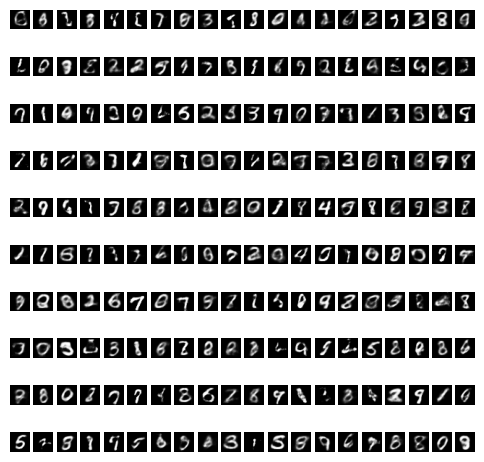

In [81]:
#generating
import matplotlib.pyplot as plt

with torch.no_grad():

    z = torch.randn(200, 20)

    generated = torch.sigmoid(model.decode(z))

    generated = generated.view(-1, 1, 28, 28)

    fig, axes = plt.subplots(10, 20, figsize=(6,6))

    for i, ax in enumerate(axes.flat):

        ax.imshow(generated[i][0], cmap='gray')

        ax.axis('off')

    plt.show()

